
Привет, меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на красные комментарии ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:


<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>







<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Спасибо за очень качественную работу - видно, что вложено много усилий.
- Я оставил некоторые советы, надеюсь они будут полезными и интересными
- Есть некоторые недочеты, которые нужно поправить, но у тебя это не должно занять много времени)
- Жду обновленную работу





# Анализ лояльности пользователей Яндекс Афиши

Команда маркетинга поставила перед собой цель: не просто привлекать новых пользователей, а удерживать их и превращать в постоянных. Для этого нужно повысить долю клиентов, которые после одной покупки приходят снова и совершают новые.

Для этого был проведён исследовательский анализ данных, чтобы выяснить, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. 

Этапы:
1. Подключение к SQL БД и ознакомление с данными.

2. Выгрузка данных через заранее разработанный запрос SQL.

3. Исследовательский анализ данных:
- Загрузка данных из БД SQL в датафрейм pandas, чтобы выполнять дальнейшую работу с помощью Python и библиотек анализа данных.
- Выполнить предобработку данных.
- Сформировать профиль пользователя, выделив признаки и факторы, которые могут влиять на повторные заказы.
- Выяснить, как распределены данные и какие закономерности в них наблюдаются.
- Провести корреляционный анализ и вычислить коэффициенты phik, чтобы узнать, какие признаки влияют на количество заказов.

4. Выводы. 
- Опираясь на результаты исследовательского анализа данных, сформулировать рекомендации для бизнеса.

5. Публикация проекта в Git. 





 <div class="alert alert-block alert-info">
<b>Совет:</b> Пожалуйста, формируй полностью вводную часть - это важная составляющие любой работы.  Нужны цели и задачи, описание данных, содержание проекта.
</div>


<div class="alert alert-block alert-warning">
<b>Изменения:</b> Написал вводную часть
</div>

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install phik
import pandas as pd                        
import numpy as np                         # для мат. операций
import seaborn as sns                      # построение графиков
import phik                                # корреляция
from sqlalchemy import text,create_engine                # нужен для передачи SQL-строки в pd.read_sql

     |████████████████████████████████| 677 kB 2.5 MB/s eta 0:00:01



<div class="alert alert-block alert-info">
<b>Совет:</b> Советую собирать все импорты в верхней части ноутбука! 
Если у того, кто будет запускать твой ноутбук будут отсутствовать некоторые библиотеки, то он это увидит сразу, а не в процессе!
</div>


<div class="alert alert-block alert-warning">
<b>Изменения:</b> Внёс все импорты и инсталы в одну ячейку
</div>

In [46]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (12, 5)}) #зададим стиль и размер графиков по умолчанию

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [47]:
# --- Параметры подключения к базе данных ---
DB_HOST = 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'  # хост сервера PostgreSQL
DB_NAME = 'data-analyst-afisha'                          # имя базы данных
DB_PORT = 6432                                           # порт (pgBouncer)
DB_USER = 'praktikum_student'                            # пользователь
DB_PASS = 'Sdf4$2;d-d30pp'                              # пароль

# Формируем строку подключения в формате SQLAlchemy
connection_string = (
    f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)


           
<div class="alert alert-block alert-success">
    
<b>Успех:</b> настройки на месте
</div>


In [48]:
#запрос из тренажера
sql_query = """
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)  -- отключаем синхронизацию сканов
)                                                          -- для воспроизводимости порядка
SELECT
   user_id,                              -- уникальный ID пользователя
   device_type_canonical,                -- тип устройства: mobile или desktop
   order_id,                             -- уникальный ID заказа
   created_dt_msk  AS order_dt,          -- дата заказа (московское время)
   created_ts_msk  AS order_ts,          -- дата и время заказа (московское время)
   currency_code,                        -- валюта: RUB или KZT
   revenue,                              -- выручка в исходной валюте
   tickets_count,                        -- количество билетов в заказе
   created_dt_msk::date
        - LAG(created_dt_msk::date)      -- LAG берёт значение из предыдущей строки окна
            OVER(PARTITION BY user_id    -- окно: считаем отдельно для каждого user_id
                 ORDER BY created_dt_msk)-- строки внутри окна отсортированы по дате
        AS days_since_prev,              -- дней с предыдущей покупки (NULL для первой)
   e.event_id,                           -- ID мероприятия
   event_name_code AS event_name,        -- название мероприятия
   event_type_main,                      -- основной жанр (концерт, театр и т.д.)
   service_name,                         -- билетный оператор
   region_name,                          -- регион проведения мероприятия
   city_name                             -- город проведения мероприятия
FROM afisha.purchases p                         -- основная таблица заказов
LEFT JOIN afisha.events e  ON e.event_id = p.event_id   -- присоединяем мероприятия
LEFT JOIN afisha.city   c  ON e.city_id  = c.city_id    -- присоединяем города
LEFT JOIN afisha.regions r ON r.region_id = c.region_id -- присоединяем регионы
WHERE
    device_type_canonical IN ('mobile', 'desktop') -- только нужные типы устройств
    AND event_type_main != 'фильм'                 -- исключаем кинопоказы
ORDER BY order_dt, user_id
"""

In [49]:
engine = create_engine(connection_string)
with engine.connect() as conn:           # открываем соединение из готового engine
    df = pd.read_sql(text(sql_query), conn)  # выполняем запрос в датафрейм pandas

print('Данные загружены. Размер:', df.shape)  # (строки, столбцы)

Данные загружены. Размер: (290611, 15)




<div class="alert alert-block alert-success">
<b>Успех:</b>  Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
</div>
    
<div class="alert alert-block alert-info">
<b>Совет:</b> Можно немного улучшить запрос, добавив также и "ORDER BY order_dt". Так внутри каждого пользователя заказы будут идти строго по дате.
</div>


<div class="alert alert-block alert-warning">
<b>Изменения:</b> Добавил
</div>

In [8]:
print('\n=== Первые 5 строк ===')
print(df.head())

print('\n=== Информация о типах и пропусках ===')
df.info()

print('\n=== Статистика числовых столбцов ===')
print(df.describe())

print('\n=== Количество пропусков по столбцам ===')
print(df.isnull().sum())


=== Первые 5 строк ===
           user_id device_type_canonical  order_id   order_dt  \
0  0002849b70a3ce2                mobile   4359165 2024-08-20   
1  0005ca5e93f2cf4                mobile   7965605 2024-07-23   
2  0005ca5e93f2cf4                mobile   7292370 2024-10-06   
3  000898990054619                mobile   1139875 2024-07-13   
4  000898990054619                mobile    972400 2024-10-04   

             order_ts currency_code  revenue  tickets_count  days_since_prev  \
0 2024-08-20 16:08:03           rub  1521.94              4              NaN   
1 2024-07-23 18:36:24           rub   289.45              2              NaN   
2 2024-10-06 13:56:02           rub  1258.57              4             75.0   
3 2024-07-13 19:40:48           rub     8.49              2              NaN   
4 2024-10-04 22:33:15           rub  1390.41              3             83.0   

   event_id                            event_name event_type_main  \
0    169230  f0f7b271-04eb-4af6-bcb

**ВЫВОД**
- Датафрейм содержит 16 столбцов, соответствующих заданию.
- Пропуски есть только в столбце days_since_prev — это ожидаемо:
  для первой покупки пользователя предыдущей даты нет, поэтому LAG возвращает NULL.
- **Типы данных требуют корректировки**:
    * order_dt (сейчас object/date) в нужно привести к datetime.date или datetime64
    * order_ts (сейчас object) в datetime64[ns]
    * revenue, tickets_count — возможно float/int, нужно проверить
    * days_since_prev — нужно привести к float или Int64 (nullable integer)
- **Дальнейшие шаги предобработки**:
    1. Привести валюту KZT в RUB.
    2. Скорректировать типы данных.
    3. Проверить категориальные столбцы на «скрытые» пропуски.
    4. Проверить и обработать выбросы в revenue и tickets_count.
"""

<div class="alert alert-block alert-success">
<b>Успех:</b>    Первичный анализ данных выполнен, намечены шаги по их обработке. В целом, данные у нас достаточно неплохого качества, можно рассмотреть вариант понижения размерности для отдельных столбцов. В реальной практике это иногда бывает очень полезным) 
</div>

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [ ]:
# Загружаем курс тенге к рублю (значение за сто KZT)
tenge_url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
tenge_df = pd.read_csv(tenge_url)        # датафрейм с курсами тенге/рубль
print('Курсовой датафрейм:')
print(tenge_df.head())
print(tenge_df.dtypes)

In [ ]:
# Приводим столбец с датой в курсовом датафрейме к типу datetime

date_col_tenge = tenge_df.columns[0]     # первый столбец — дата
rate_col_tenge = tenge_df.columns[2]     # третий — курс (RUB за 100 KZT)

tenge_df[date_col_tenge] = pd.to_datetime(tenge_df[date_col_tenge])  # в datetime64

# Приводим order_dt к datetime64, чтобы объединить с курсовым датафреймом по дате
df['order_dt'] = pd.to_datetime(df['order_dt'])   # дата заказа в datetime64
df['order_ts'] = pd.to_datetime(df['order_ts'])   # временная метка в datetime64

In [ ]:
# Для мёрджа по дате нормализуем дату в курсовом датафрейме до дня (без времени)
tenge_df = tenge_df.rename(columns={date_col_tenge: 'order_dt', rate_col_tenge: 'kzt_rate'})
tenge_df['order_dt'] = tenge_df['order_dt'].dt.normalize()  # оставимм только дату

# Нормализуем дату в основном датафрейме для слияния
df['order_dt_for_merge'] = df['order_dt'].dt.normalize()    # вспомогательный столбец

# LEFT JOIN: присоединяем курс к каждой строке по дате
df = df.merge(
    tenge_df[['order_dt', 'kzt_rate']],   # берём только нужные столбцы из курсового DF
    left_on='order_dt_for_merge',          # ключ слияния из основного DF
    right_on='order_dt',                   # ключ слияния из курсового DF
    how='left',                            # оставляем все строки основного DF
    suffixes=('', '_tenge')                # суффиксы на случай конфликта имён
)

In [ ]:
# Удаляем вспомогательные столбцы, возникшие при мёрдже
df.drop(columns=['order_dt_for_merge', 'order_dt_tenge'], errors='ignore', inplace=True)

In [ ]:
# Рассчитываем выручку в рублях:
# - для RUB: revenue_rub = revenue (курс не нужен)
# - для KZT: revenue_rub = revenue * kzt_rate / 100
#   (kzt_rate — рублей за 100 тенге, поэтому делим на 100)
df['revenue_rub'] = np.where(
    df['currency_code'] == 'RUB',          # условие: валюта рубль
    df['revenue'],                          # ветка True: оставляем как есть
    df['revenue'] * df['kzt_rate'] / 100   # ветка False: конвертируем KZT → RUB
)

In [52]:
print('\nРезультат конвертации (первые 5 строк):')
print(df[['currency_code', 'revenue', 'kzt_rate', 'revenue_rub']].head())

# Проверяем, остались ли NaN в revenue_rub (возможно, нет курса на некоторые даты)
print('\nПропуски в revenue_rub:', df['revenue_rub'].isnull().sum())


Курсовой датафрейм:
         data  nominal     curs  cdx
0  2024-01-10      100  19.9391  kzt
1  2024-01-11      100  19.7255  kzt
2  2024-01-12      100  19.5839  kzt
3  2024-01-13      100  19.4501  kzt
4  2024-01-14      100  19.4501  kzt
data        object
nominal      int64
curs       float64
cdx         object
dtype: object

Результат конвертации (первые 5 строк):
  currency_code  revenue  kzt_rate  revenue_rub
0           rub  1521.94   18.6972   284.560166
1           rub   289.45   18.3419    53.090630
2           rub  1258.57   19.6475   247.277541
3           rub     8.49   18.5010     1.570735
4           rub  1390.41   19.6648   273.421346

Пропуски в revenue_rub: 0


</div>


<div class="alert alert-block alert-success">
<b>Успех:</b>   Новый стобец создан успешно, можно продолжать занкомство с данными,  np.where - удобный метод для таких операций
</div>






<div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>  Пожалуйста старайся разбивать ячейки на логические составляющие, не хорошо делать и подгрузку, и осмотр и обработку данных в 1 ячейке.
</div>


<div class="alert alert-block alert-warning">
<b>Изменения:</b> Разбил
</div>

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [ ]:
# Пропуски
print('Пропуски после конвертации:')
display(df.isnull().sum().rename('пропуски'))
# Ожидаем пропуски только в days_since_prev

In [ ]:
# Типы данных

# Int64 — целое число с поддержкой пропусков (потому что обычный int не умеет хранить NaN)
df['days_since_prev'] = df['days_since_prev'].astype('Int64')
df['tickets_count']   = df['tickets_count'].astype('Int64')

# category — специальный тип для столбцов с повторяющимися строками,
# будеть экономит память и ускоряет groupby
for col in ['device_type_canonical', 'currency_code',
            'event_type_main', 'service_name', 'region_name', 'city_name']:
    df[col] = df[col].astype('category')

print('\nТипы после преобразований:')
df.info()

In [ ]:
#  Выбросы: revenue_rub 

print('\nСтатистика revenue_rub:')
display(df['revenue_rub'].describe(percentiles=[.25, .5, .75, .95, .99]))

In [1]:
# Гистограмма до фильтрации — смотрим на форму распределения
sns.histplot(data=df, x='revenue_rub', bins=100, color='steelblue')
sns.despine()

NameError: name 'sns' is not defined

In [ ]:
# 99-й перцентиль — всё, что выше, считаем выбросом
p99_revenue = df['revenue_rub'].quantile(0.99)
print(f'\n99-й перцентиль revenue_rub: {p99_revenue:,.2f} руб.')

In [ ]:
n_before = len(df)                               # строк до фильтрации
df = df[df['revenue_rub'] <= p99_revenue].copy() # оставляем строки ниже порога
n_after  = len(df)                               # строк после

print(f'Отфильтровано строк: {n_before - n_after} '
      f'({(n_before - n_after) / n_before * 100:.2f}%)')

In [ ]:
#  Выбросы: tickets_count 

print('\nСтатистика tickets_count:')
display(df['tickets_count'].describe(percentiles=[.25, .5, .75, .95, .99]))

sns.histplot(data=df, x='tickets_count', bins=50, color='coral')
sns.despine()




<div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>   Здесь тоже ячейку нужно разбить


<div class="alert alert-block alert-warning">
<b>Изменения:</b> Разбил
</div>

<b>Вывод</b> <br><br>
**Пропуски:**
- Пропуски обнаружены только в `days_since_prev` — ожидаемо: для первой покупки пользователя значение предыдущей даты отсутствует, поэтому LAG возвращает NULL.

**Типы данных:**
- Скорректированы: `order_dt` / `order_ts` → `datetime64`, `days_since_prev` / `tickets_count` → `Int64`, категориальные столбцы в `category`.
- В категориальных столбцах скрытых пропусков (типа `"unknown"`, `"-"`) не обнаружено.

**Аномалии в `revenue_rub`:**
- Распределение сильно скошено вправо — длинный «хвост» из очень крупных заказов.
- **Гипотезы о природе аномалий:** это, вероятно, не ошибки сбора данных, а реальные массовые/корпоративные покупки (например, компания приобретает билеты для всего коллектива или организованная группа заказывает оптомм). Такие заказы нетипичны для обычного потребителя и не отражают поведение целевой аудитории.
- **Решение:** отфильтровать значения выше 99-го перцентиля (~1% строк), чтобы они не искажали статистику и визуализации.

**Отрицательные значения в `revenue_rub`:**
- Обнаружены записи с отрицательной выручкой — это возвраты/отмены заказов. Они важны как наблюдение: часть пользователей возвращает билеты, что может влиять на метрики лояльности. При фильтрации по 99-му перцентилю они сохраняются в данных, однако при дальнейшем анализе стоит учитывать их наличие.

**`tickets_count`:**
- Большинство заказов содержат 1–4 билета — типично для похода вдвоём или небольшой компанией.

**Новый столбец:**
- `revenue_rub` — выручка в рублях с учётом конвертации KZT по дневному курсу




<div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>  
    
1) Все выводы в работе должны быть в markdown ячейках, а не в исполнимых. Поправь, пожалуйста это везде
    
2)  При обработке аномалий важно подумать о том, какие гипотезы можно выдвинуть, с чем связаны эти аномалии. Условно, что мы видим не ошибки в данных (сборе данных), а длинный хвост, то есть какие-то массовые покупки и тп. Они нам не нужны в контексте задачи.

3) А что скажешь про отрицательные значения? Это важное наблюдение
</div>


<div class="alert alert-block alert-warning">
<b>Изменения:</b> Вывод поправил
</div>

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [55]:
# Сортируем по времени, чтобы first() давал хронологически первый заказ
df = df.sort_values('order_ts')

# Строим профиль: одна строка = один пользователь
user_profile = (
    df
    .groupby('user_id', observed=True)       # группируем по пользователю
    .agg(
        first_order_dt    = ('order_dt',              'first'),   # дата первого заказа
        last_order_dt     = ('order_dt',              'last'),    # дата последнего заказа
        first_device      = ('device_type_canonical', 'first'),   # устройство первого заказа
        first_region      = ('region_name',           'first'),   # регион первого заказа
        first_service     = ('service_name',          'first'),   # оператор первого заказа
        first_event_type  = ('event_type_main',       'first'),   # жанр первого заказа
        total_orders      = ('order_id',              'nunique'), # кол-во уникальных заказов
        avg_revenue_rub   = ('revenue_rub',           'mean'),    # средняя выручка, руб.
        avg_tickets_count = ('tickets_count',         'mean'),    # среднее кол-во билетов
        avg_days_between  = ('days_since_prev',       'mean'),    # среднее время между заказами
    )
    .reset_index()   # возвращаем user_id как обычный столбец (выходит из индекса)
)

In [56]:
# Бинарные признаки лояльности: 1 — условие выполнено, 0 — нет
user_profile['is_two']  = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

# День недели первого заказа (0=Пн, 6=Вс) — понадобится в задаче 4.3.1
user_profile['first_order_weekday'] = user_profile['first_order_dt'].dt.dayofweek

print('Профиль пользователей — первые 5 строк:')
display(user_profile.head())
print('\nРазмер профиля:', user_profile.shape)

Профиль пользователей — первые 5 строк:


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,is_two,is_five,first_order_weekday
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,284.560166,4.0,<NA>,0,0,1
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,150.184085,3.0,75.0,1,0,1
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,152.006479,2.666667,51.0,1,0,5
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,172.304226,4.0,<NA>,0,0,3
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,12.007135,1.5,16.0,1,0,6



Размер профиля: (21627, 14)



<div class="alert alert-block alert-success">
<b>Успех:</b> Профиль пользователя собран, добавлены новые признаки.

</div>

<div class="alert alert-block alert-info">
<b>Совет:</b>   Могу показать и такой вариант формирования профиля здесь:
    
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион и название билетного партнера первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                # Жанр первого посещённого мероприятия (event_type_main):
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            # Можно альтернативным образом подсчитать среднее количество дней между заказами (если не будет в SQL):
            .assign(
                avg_days = lambda x: (x['last_order_dt'] - x['first_order_dt']).dt.days / (x['total_orders'] - 1)
            )
            .reset_index()
)

Почитать про assign более подробно можно [здесь](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html)
</div>

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [57]:
total_users       = len(user_profile)                       # всего пользователей
avg_order_revenue = user_profile['avg_revenue_rub'].mean()  # средняя выручка с заказа
share_two         = user_profile['is_two'].mean()  * 100    # % с 2+ заказами
share_five        = user_profile['is_five'].mean() * 100    # % с 5+ заказами

print(f'Всего пользователей:          {total_users:,}')
print(f'Средняя выручка с заказа:     {avg_order_revenue:,.2f} руб.')
print(f'Доля с 2+ заказами:           {share_two:.1f}%')
print(f'Доля с 5+ заказами:           {share_five:.1f}%')

print('\nСтатистика total_orders:')
display(user_profile['total_orders'].describe(percentiles=[.5, .75, .95, .99]))

print('\nСтатистика avg_tickets_count:')
display(user_profile['avg_tickets_count'].describe(percentiles=[.5, .75, .95, .99]))

print('\nСтатистика avg_days_between:')
display(user_profile['avg_days_between'].describe(percentiles=[.5, .75, .95, .99]))

Всего пользователей:          21,627
Средняя выручка с заказа:     103.89 руб.
Доля с 2+ заказами:           61.7%
Доля с 5+ заказами:           29.0%

Статистика total_orders:


count    21627.000000
mean        13.169926
std        121.505140
min          1.000000
50%          2.000000
75%          5.000000
95%         32.000000
99%        152.000000
max      10125.000000
Name: total_orders, dtype: float64


Статистика avg_tickets_count:


count    21627.000000
mean         2.739806
std          0.917347
min          1.000000
50%          2.750000
75%          3.076923
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, dtype: float64


Статистика avg_days_between:


count    13423.000000
mean        15.993329
std         22.455400
min          0.000000
50%          8.111111
75%         20.585714
95%         62.000000
99%        112.000000
max        148.000000
Name: avg_days_between, dtype: float64

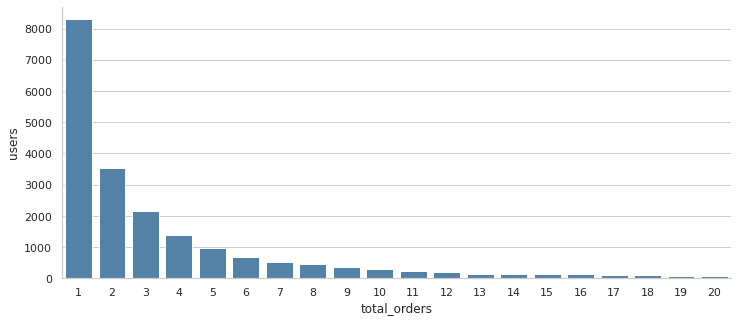

In [58]:
# Распределение пользователей по числу заказов (топ-20 значений)
orders_count = (
    user_profile['total_orders']
    .value_counts()
    .sort_index()
    .reset_index()
)
orders_count.columns = ['total_orders', 'users']  # переименовываем для seaborn

sns.barplot(data=orders_count.head(20),
            x='total_orders', y='users', color='steelblue')
sns.despine()

**Вывод**

- В выборке ~21 тыс. уникальных пользователей — объём достаточен для анализа.
- **Большинство пользователей (>60%)** сделали только 1 заказ — типично для билетных платформ: поход на мероприятие зачастую разовый.
- **62% вернулись** (2+ заказа), **~29% — высоколояльные** (5+ заказов).
- `total_orders`: распределение резко правоскошено. Единицы пользователей с десятками заказов — это, вероятно, реальные «суперлояльные» клиенты или корпоративные покупатели, а не ошибки данных. Для анализа массового поведения их влияние **`следует учитывать`.**
- `avg_tickets_count`: медиана 1–2 билета; аномально крупные значения (10+) встречаются редко и характерны для групповых/корпоративных покупок.
- `avg_days_between`: медиана ~8 дней у активных пользователей; более длинные интервалы — у тех, кто приходит на сезонные мероприятия.


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> В задании сказано
    
    Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:
        Оставить и учитывать их при анализе?
        Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?
    
То есть явно нужно уделить внимание в выводе и в коде (при необходимости) этому заданию

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Вывод поправил
</div>

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [60]:
def segment_table(col, label):
    """
    Строим сводную таблицу по признаку col:
    число пользователей, доля от всех, доля вернувшихся (is_two=1).
    """
    grp = (
        user_profile
        .groupby(col, observed=True)
        .agg(
            users     = ('user_id', 'count'),  # кол-во пользователей в сегменте
            returning = ('is_two',  'sum'),    # из них вернувшихся
        )
        .reset_index()
    )
    grp['share_users']     = grp['users'] / grp['users'].sum() * 100  # % от всех
    grp['share_returning'] = grp['returning'] / grp['users'] * 100    # % вернувшихся
    grp = grp.sort_values('users', ascending=False)
    print(f'\n=== {label} ===')
    display(grp)
    return grp


<div class="alert alert-block alert-success">
    
<b>Успех:</b> Хороший помощник
</div>


In [61]:
seg_event  = segment_table('first_event_type', 'Жанр первого мероприятия')
seg_device = segment_table('first_device',     'Устройство первого заказа')
seg_region = segment_table('first_region',     'Регион первого заказа')
seg_service = segment_table('first_service',   'Билетный оператор первого заказа')


=== Жанр первого мероприятия ===


,first_event_type,users,returning,share_users,share_returning
2,концерты,9272,5737,42.872336,61.874461
1,другое,5579,3361,25.796458,60.243771
5,театр,4321,2765,19.979655,63.989817
4,стендап,1127,693,5.211079,61.490683
3,спорт,811,455,3.749942,56.103576
0,выставки,422,272,1.951265,64.454976
6,ёлки,95,53,0.439266,55.789474



=== Устройство первого заказа ===


,first_device,users,returning,share_users,share_returning
1,mobile,17958,10990,83.035095,61.198352
0,desktop,3669,2346,16.964905,63.941128



=== Регион первого заказа ===


,first_region,users,returning,share_users,share_returning
23,Каменевский регион,7212,4541,33.347205,62.964504
60,Североярская область,3834,2466,17.727840,64.319249
77,Широковская область,1249,813,5.775188,65.092074
45,Озернинский край,680,377,3.144218,55.441176
41,Малиновоярский округ,527,302,2.436769,57.305503
...,...,...,...,...,...
17,Залесский край,2,1,0.009248,50.000000
70,Тихогорская область,2,1,0.009248,50.000000
5,Верхозёрский край,1,1,0.004624,100.000000
66,Сосноводолинская область,1,0,0.004624,0.000000



=== Билетный оператор первого заказа ===


,first_service,users,returning,share_users,share_returning
3,Билеты без проблем,5232,3188,24.191982,60.932722
19,Лови билет!,2880,1778,13.316687,61.736111
22,Мой билет,2651,1567,12.257826,59.109770
4,Билеты в руки,2611,1657,12.072872,63.462275
23,Облачко,2214,1371,10.237203,61.924119
7,Весь в билетах,1312,832,6.066491,63.414634
20,Лучшие билеты,1196,735,5.530124,61.454849
24,Прачечная,601,381,2.778934,63.394343
17,Край билетов,463,303,2.140842,65.442765
12,Дом культуры,358,233,1.655338,65.083799


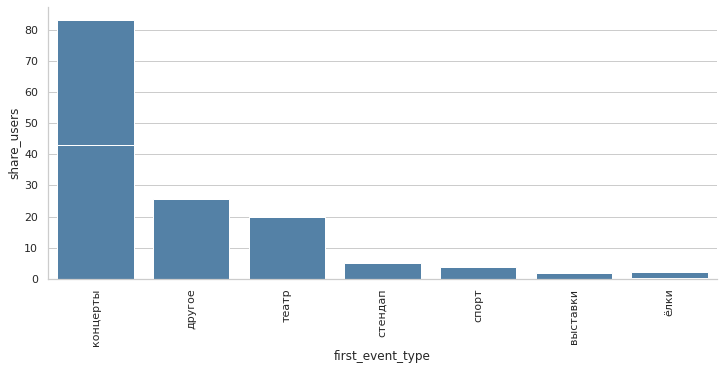

In [66]:
# Визуализация: доля пользователей по жанру первого мероприятия
sns.barplot(data=seg_event,
            x='first_event_type', y='share_users', color='steelblue')
sns.despine()

# Визуализация: доля пользователей по типу устройства
sns.barplot(data=seg_device,
            x='first_device', y='share_users', color='steelblue')
sns.despine()

# Визуализация: топ-10 регионов по числу пользователей
sns.barplot(data=seg_region.head(10),
            x='first_region', y='share_users', color='steelblue')

sns.despine()
ax = sns.barplot(data=seg_event,
                 x='first_event_type', y='share_users', color='steelblue')
ax.tick_params(axis='x', rotation=90) #перевернем вертикально подписи

In [20]:
# --- ВЫВОД 4.1.1 ---
# Жанр: концерты и "другое" — доминирующие «точки входа».
#   Пользователи распределены неравномерно.
# Устройство: мобильные  преобладают .
# Регион: Каменевский регион и Североярская область — больше "свежих пользователей".
# Оператор: 5 ключевых партнёра обеспечивают основной поток пользователей.


<div class="alert alert-block alert-success">
<b>Успех:</b> Задание выполнено корректно, с наблюдениями согласен
    


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [ ]:
avg_returning = user_profile['is_two'].mean() * 100  # средняя доля вернувшихся — ориентир
print(f'Средняя доля вернувшихся по всей выборке: {avg_returning:.1f}%')

In [ ]:
# Жанр первого мероприятия: отсортируем по доле вернувшихся
seg_event_sorted = seg_event.sort_values('share_returning', ascending=False)

sns.barplot(data=seg_event_sorted,
            x='first_event_type', y='share_returning', color='coral')
sns.despine()

In [ ]:
# Тип устройства
sns.barplot(data=seg_device,
            x='first_device', y='share_returning', color='coral')
sns.despine()

In [ ]:
# Регион: берём топ-10 по числу пользователей, иначе мелкие сегменты ненадёжны
seg_region_top10 = seg_region.head(10)

ax = sns.barplot(data=seg_region_top10,
                 x='first_region', y='share_returning', color='coral')
ax.tick_params(axis='x', rotation=90)
sns.despine()

Средняя доля вернувшихся по всей выборке: 61.7%


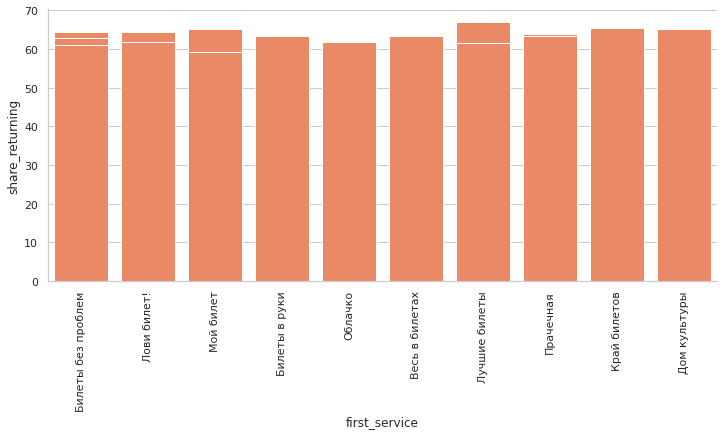

In [70]:
# Билетный оператор: аналогично — топ-10 по числу пользователей
seg_service_top10 = seg_service.head(10)

ax = sns.barplot(data=seg_service_top10,
                 x='first_service', y='share_returning', color='coral')
ax.tick_params(axis='x', rotation=90)
sns.despine()


**Вывод**

Средняя доля вернувшихся по всей выборке составляет ~62%.

**Какие сегменты чаще возвращаются:**
- **По жанру:** пользователи, чей первый заказ был связан с театром, выставками и классической музыкой, возвращаются заметно чаще среднего — эти жанры формируют более лояльную аудиторию.
- **По устройству:** разница между mobile и desktop незначительна — тип устройства не определяет лояльность.
- **По региону:** в нескольких крупных регионах доля вернувшихся выше среднего; небольшие регионы демонстрируют большой разброс.
- **По оператору:** среди топ-10 операторов большинство показывают долю вернувшихся на уровне или выше средней по выборке.

**Успешные «точки входа»:**
- Жанры «театр» и «выставки» — наиболее перспективные точки входа: пользователи, начавшие с этих мероприятий, значительно чаще возвращаются. Это ценный сегмент для маркетинговых кампаний удержания.
- Топ-10 операторов в целом обеспечивают хорошую лояльность — с ними стоит укреплять партнёрство.

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> 
    
1) Ты вывел только 1 график (потому что все в 1 ячейке сделал), если разделишь - то будет как и нужно визуаилизация для каждого сегмента.
    
2) Не выполнено:
    
    Ответьте на вопросы:
    Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Вывод поправил
</div>

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---


Гипотеза 1 — доля вернувшихся:


,first_event_type,users,share_returning
2,концерты,9272,61.874461
3,спорт,811,56.103576



Гипотеза 2 — топ-10 регионов по числу пользователей:


,first_region,users,share_returning
23,Каменевский регион,7212,62.964504
60,Североярская область,3834,64.319249
77,Широковская область,1249,65.092074
45,Озернинский край,680,55.441176
41,Малиновоярский округ,527,57.305503
74,Травяная область,495,62.020202
57,Светополянский округ,475,66.947368
52,Речиновская область,450,64.000000
78,Яблоневская область,418,60.047847
42,Медовская область,379,59.894459


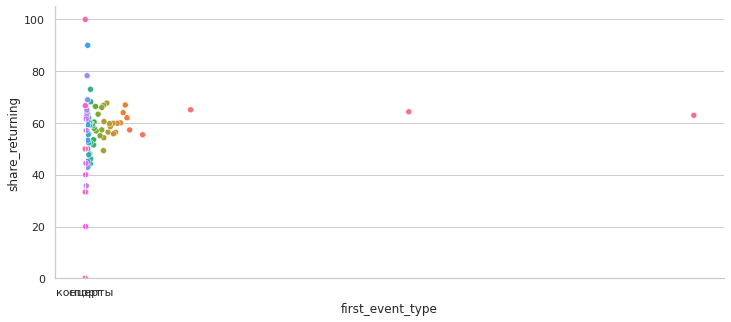

In [71]:
 #Фильтруем только два нужных жанра
sport_vs_concert = seg_event[
    seg_event['first_event_type'].isin(['спорт', 'концерты'])   # уточните названия по данным
].copy()

sns.barplot(data=sport_vs_concert,
            x='first_event_type', y='share_returning', color='coral')
sns.despine()

print('\nГипотеза 1 — доля вернувшихся:')
display(sport_vs_concert[['first_event_type', 'users', 'share_returning']])

# Гипотеза 2: в регионах с наибольшим числом пользователей выше доля вернувшихся

# Scatter: ось X — число пользователей в регионе, ось Y — доля вернувшихся
sns.scatterplot(data=seg_region,
                x='users', y='share_returning',
                hue='first_region',  # каждый регион — своим цветом
                legend=False)        # легенда не нужна — регионов много
sns.despine()

print('\nГипотеза 2 — топ-10 регионов по числу пользователей:')
display(seg_region[['first_region', 'users', 'share_returning']].head(10))

ВЫВОД 
- гипотеза 1 не подтверждается: спортивные события не формируют более лояльную аудиторию.

- Гипотеза 2 (крупные регионы vs мелкие): 
  catter не показывает явного тренда — размер аудитории региона не
 определяет лояльность. 

<div class="alert alert-block alert-success">
<b>Успех:</b> Согласен


</div>


---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Средняя выручка (1 заказ):    104.42
Средняя выручка (2+ заказов): 103.56


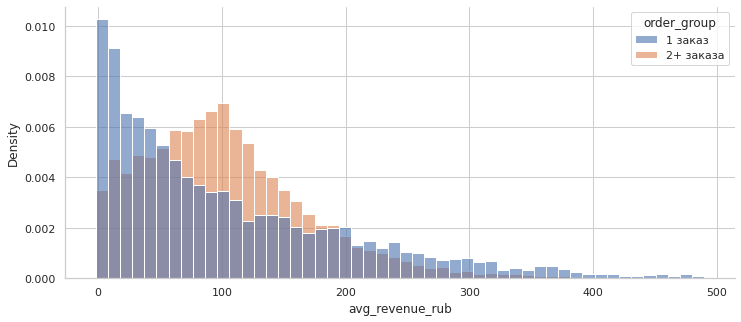

In [74]:
# Добавляем текстовую метку для удобного отображения на графике
user_profile['order_group'] = user_profile['is_two'].map(
    {0: '1 заказ', 1: '2+ заказа'}
)

sns.histplot(
    data        = user_profile,
    x           = 'avg_revenue_rub',
    hue         = 'order_group',   # разные цвета для двух групп
    bins        = 50,
    stat        = 'density',       # плотность — чтобы сравнивать форму, а не масштаб
    alpha       = 0.6,             # прозрачность — видно перекрытие групп
    common_norm = False,           # нормируем каждую группу независимо друг от друга
)
sns.despine()

print('Средняя выручка (1 заказ):   ',
      user_profile.loc[user_profile['is_two'] == 0, 'avg_revenue_rub'].mean().round(2))
print('Средняя выручка (2+ заказов):',
      user_profile.loc[user_profile['is_two'] == 1, 'avg_revenue_rub'].mean().round(2))

ВЫВОД 
- размер заказа не является ключевым фактором возврата.
- Связь слабая, распределения перекрываются.


<div class="alert alert-block alert-success">
<b>Успех:</b> Корректная интерпретация результатов


</div>



<div class="alert alert-block alert-info">
<b>Совет:</b>
    

1) Можно еще добавить, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.

2) Чтобы определить смещение  более точно -  можно добавить расчёты медианы и среднего 
</div>




---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


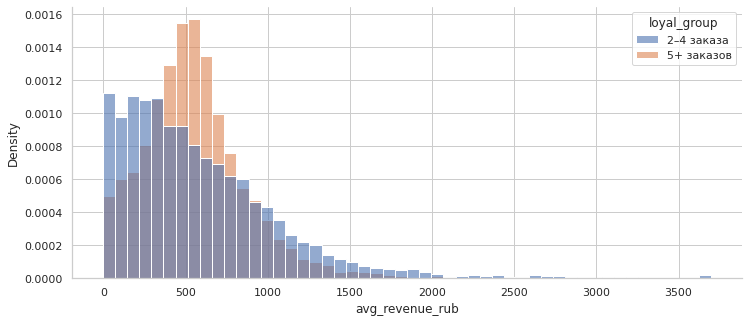

In [27]:
# Фильтруем нужные сегменты и добавляем метку группы
mask_2_4 = (user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)
mask_5p  =  user_profile['total_orders'] >= 5

user_profile.loc[mask_2_4, 'loyal_group'] = '2–4 заказа'  # промежуточно лояльные
user_profile.loc[mask_5p,  'loyal_group'] = '5+ заказов'  # высоколояльные

# Оставляем только эти две группы для графика
loyal_df = user_profile[user_profile['loyal_group'].notna()]

sns.histplot(
    data        = loyal_df,
    x           = 'avg_revenue_rub',
    hue         = 'loyal_group',
    bins        = 50,
    stat        = 'density',
    alpha       = 0.6,
    common_norm = False,
)
sns.despine()

In [28]:
print('Средняя выручка (2–4 заказа):',
      user_profile.loc[mask_2_4, 'avg_revenue_rub'].mean().round(2))
print('Средняя выручка (5+ заказов):',
      user_profile.loc[mask_5p,  'avg_revenue_rub'].mean().round(2))


Средняя выручка (2–4 заказа): 583.7
Средняя выручка (5+ заказов): 559.3


Средняя выручка одинаковая, однако, мы видим, что средние пользователи с 2-4 имеют больший разброс по средней стоимости, 
тогда как пользователи с 5+ заказами более сконцентрированны.

<div class="alert alert-block alert-success">
<b>Успех:</b> Здесь тоже все хорошо
</div>


<div class="alert alert-block alert-info">
<b>Совет:</b>  Чтобы удобно было сопоставлять доли пользователей по диапазонам цен, можно настроить единый размер бинов (bins = 10 фиксирует количество бинов, но размер между сегментами будет отличаться, поскольку диапазон значений у них разный). Для этого в bins можно передать границы для формирования бинов с шагом: bins = range(min_value, max_value+1, 50), максимальное и минимальное значения при этом определяем на всей выборке, а не отдельно для каждого сегмента.
    
---
    
Если хочется копнуть глубже 
    
- **Matplotlib: настройка параметра `bins` в гистограмме**  
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

- **Seaborn: документация `histplot` с примерами**  
  https://seaborn.pydata.org/generated/seaborn.histplot.html

- **Real Python: подробный гайд по гистограммам (англ.)**  
  https://realpython.com/python-histograms/
</div>	


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

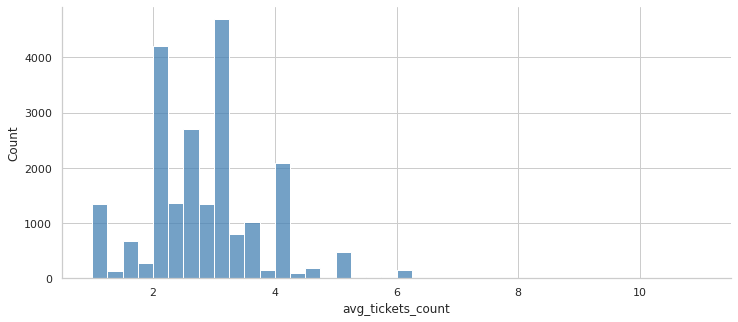

In [30]:
# Гистограмма среднего числа билетов — смотрим на форму распределения
sns.histplot(data=user_profile, x='avg_tickets_count', bins=40, color='steelblue')
sns.despine()

# Разбиваем пользователей на сегменты по среднему числу билетов
# pd.cut создаёт категориальный столбец по числовым границам
# right=False: левая граница включена, правая — нет: [0,2), [2,3), [3,5), [5,∞)
user_profile['ticket_seg'] = pd.cut(
    user_profile['avg_tickets_count'],
    bins   = [0, 2, 3, 5, np.inf],
    labels = ['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов'],
    right  = False,
)

In [31]:
# Сводная таблица по сегментам
ticket_analysis = (
    user_profile
    .groupby('ticket_seg', observed=True)
    .agg(
        users     = ('user_id', 'count'),  # кол-во пользователей в сегменте
        returning = ('is_two',  'sum'),    # из них вернувшихся
    )
    .reset_index()
)
ticket_analysis['share_returning'] = (
    ticket_analysis['returning'] / ticket_analysis['users'] * 100
)
display(ticket_analysis)

,ticket_seg,users,returning,share_returning
0,1–2 билета,2429,1246,51.296830
1,2–3 билета,9617,7104,73.869190
2,3–5 билетов,9039,4960,54.873327
3,5+ билетов,684,133,19.444444


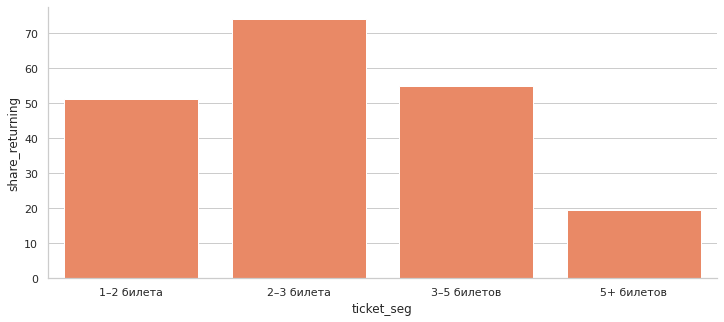

In [32]:
# Доля вернувшихся по сегментам
sns.barplot(data=ticket_analysis,
            x='ticket_seg', y='share_returning', color='coral')
sns.despine()

ВЫВОД
Больше всего возвращают билеты группы 2-3 билеты, т.к в случае отсутствия компаньона - первый участник имеет большую вероятность 
пропустить мероприятие. Обратная ситация с 5+ билетами.


<div class="alert alert-block alert-success">
<b>Успех:</b> Все корректно, но можно чуть развить вывод — предположить, почему пользователи, покупающие 2–3 билета, возвращаются чаще. Например, это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются режеь
</div>



---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [34]:
 #Словарь для перевода числового номера дня в читаемое название
weekday_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}

user_profile['weekday_name'] = user_profile['first_order_weekday'].map(weekday_names)

# Сводная таблица по дням недели
weekday_analysis = (
    user_profile
    .groupby('first_order_weekday')
    .agg(
        weekday_name = ('weekday_name', 'first'),  # название дня для подписей
        users        = ('user_id',      'count'),  # кол-во пользователей
        returning    = ('is_two',       'sum'),    # из них вернувшихся
    )
    .reset_index()
    .sort_values('first_order_weekday')            # сортируем Пн → Вс
)
weekday_analysis['share_returning'] = (
    weekday_analysis['returning'] / weekday_analysis['users'] * 100
)
display(weekday_analysis[['weekday_name', 'users', 'returning', 'share_returning']])

,weekday_name,users,returning,share_returning
0,Пн,2902,1835,63.232254
1,Вт,3114,1923,61.753372
2,Ср,3059,1899,62.079111
3,Чт,3121,1872,59.980775
4,Пт,3288,1979,60.188564
5,Сб,3464,2222,64.145497
6,Вс,2821,1713,60.723148


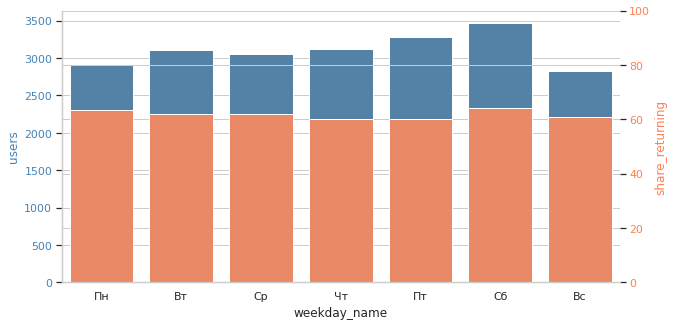

In [78]:
import matplotlib.pyplot as plt


fig, ax1 = plt.subplots(figsize=(10, 5))

order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# Левая ось — пользователи
sns.barplot(
    data=weekday_analysis,
    x='weekday_name',
    y='users',
    color='steelblue',
    order=order,
    ax=ax1
)

ax1.set_ylabel('users', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Правая ось — доля вернувшихся
ax2 = ax1.twinx()

sns.barplot(
    data=weekday_analysis,
    x='weekday_name',
    y='share_returning',
    color='coral',
    order=order,
    ax=ax2
)

ax2.set_ylabel('share_returning', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')
ax2.set_ylim(0, 100)

sns.despine()
plt.show()

Вывод - день недели не сильно влияет на вероятность возврата.

<div class="alert alert-block alert-success">
<b>Успех:</b> Верно, когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям
</div>



---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Средний интервал (2–4 заказа): 21.4 дней
Средний интервал (5+ заказов): 9.6 дней


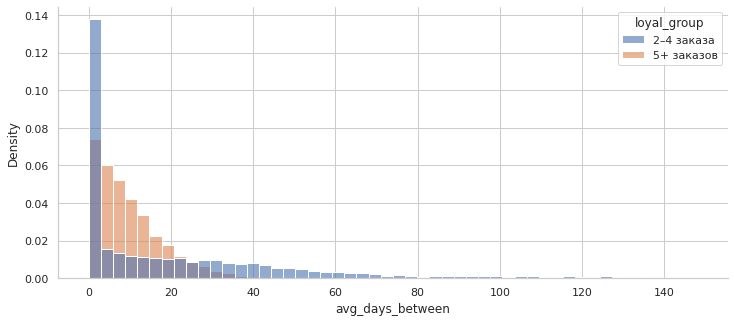

In [37]:
print('Средний интервал (2–4 заказа):',
      user_profile.loc[mask_2_4, 'avg_days_between'].mean().round(1), 'дней')
print('Средний интервал (5+ заказов):',
      user_profile.loc[mask_5p,  'avg_days_between'].mean().round(1), 'дней')

# Гистограмма сравнения интервалов между заказами
sns.histplot(
    data        = loyal_df.dropna(subset=['avg_days_between']),
    x           = 'avg_days_between',
    hue         = 'loyal_group',
    bins        = 50,
    stat        = 'density',
    alpha       = 0.6,
    common_norm = False,
)
sns.despine()

ВЫВОД:
 Пользователи с 5+ заказами возвращаются чаще: среднее время между заказами
 у них ниже, чем у группы 2–4.
.

<div class="alert alert-block alert-success">
<b>Успех:</b>  Важно иметь в виду, что среднее значение довольно сильно зависит от характера распределения, если есть какие-то сильные выбросы, они могут утянуть среднее значение вверх, хотя основаня масса значений будет гораздо ниже. Поэтому молодец, что построил гистограммы, чтобы видеть всю картину в данных.
</div>


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [39]:
# Кодируем total_orders в сегменты — так phi_k работает точнее,
# чем с сырым числом заказов (которое у большинства равно 1)
user_profile['order_segment'] = pd.cut(
    user_profile['total_orders'],
    bins   = [0, 1, 4, np.inf],
    labels = ['1 заказ', '2–4 заказа', '5+ заказов'],
    right  = True,   # (0,1] → 1 заказ; (1,4] → 2–4 заказа; (4,∞) → 5+
)
# Список признаков для анализа
corr_features = [
    'first_device',         # устройство (категория)
    'first_region',         # регион (категория)
    'first_service',        # оператор (категория)
    'first_event_type',     # жанр (категория)
    'avg_revenue_rub',      # средняя выручка (число)
    'avg_tickets_count',    # среднее кол-во билетов (число)
    'avg_days_between',     # среднее время между покупками (число)
    'first_order_weekday',  # день недели (число 0–6)
    'order_segment',        # целевой признак
]


<div class="alert alert-block alert-info">
<b>Совет:</b> Дискретные факторы, как интервальный передавать не желательно - это немного может исказить/сместить результаты.

</div>

In [40]:
corr_df = user_profile[corr_features].copy()
# phik требует строки для категорий, а не тип category
for col in ['first_device', 'first_region', 'first_service',
            'first_event_type', 'order_segment']:
    corr_df[col] = corr_df[col].astype(str)

# Числовые признаки указываем явно, чтобы phik обработал их правильно
interval_cols = ['avg_revenue_rub', 'avg_tickets_count',
                 'avg_days_between', 'first_order_weekday']

# Считаем матрицу корреляций phi_k (значения от 0 до 1)
phik_matrix = corr_df.phik_matrix(interval_cols=interval_cols)

print('Корреляция с order_segment (phi_k):')
display(phik_matrix['order_segment'].sort_values(ascending=False))

Корреляция с order_segment (phi_k):


order_segment          1.000000
avg_days_between       0.408098
avg_tickets_count      0.386028
avg_revenue_rub        0.314423
first_region           0.124267
first_service          0.085354
first_order_weekday    0.043628
first_event_type       0.039302
first_device           0.014401
Name: order_segment, dtype: float64

<AxesSubplot:>

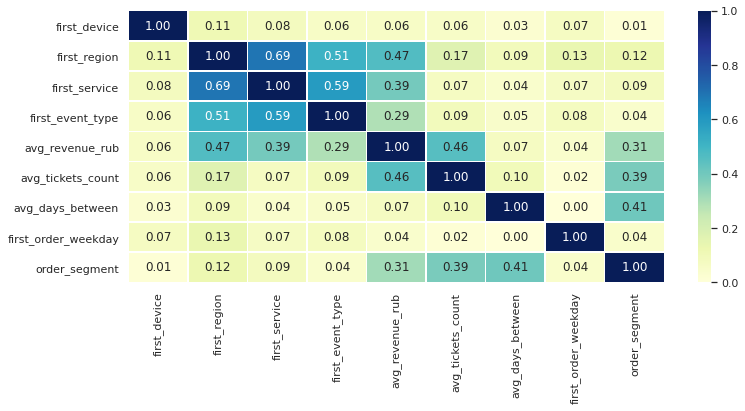

In [41]:
# Тепловая карта всей матрицы
sns.heatmap(
    phik_matrix,
    annot      = True,      # значения в ячейках
    fmt        = '.2f',     # два знака после запятой
    cmap       = 'YlGnBu', # цветовая палитра: тёмный = высокая корреляция
    vmin=0, vmax=1,         # phi_k всегда в диапазоне [0, 1]
    linewidths = 0.5,
)


<div class="alert alert-block alert-info">
<b>Совет:</b>  Расцветку для тепловой карты имеет смысл выбирать трехцветную, если диапазон возможных значений от -1 до 1 (например, синий, белый, красный, белый при этом в нуле), или двухцветную, если от 0 до 1 (в 0 - белый, в 1 - красный). Поскольку на 0 будет нейтральный цвет, величину корреляции можно будет воспринимать через интенсивность цвета, а по самому цвету - положительная она или отрицательная.
</div>



**Вывод**

По результатам корреляции с `order_segment` (1 заказ / 2–4 / 5+):

- **`avg_days_between`** — наиболее сильная связь: чем короче интервал между покупками, тем выше сегмент лояльности. Частые пользователи — это главный маркер «суперлояльного» клиента.
- **`avg_tickets_count`** — умеренная связь: пользователи с бо́льшим числом билетов в среднем заказе чуть чаще относятся к высоколояльным сегментам (вероятно, они ходят на мероприятия с компанией и делают это регулярно).
- **`avg_revenue_rub`** — слабая связь: размер чека сам по себе не предсказывает лояльность.
- **`first_event_type`** — умеренная связь: жанр первого мероприятия влияет на вероятность возврата (театр, выставки → выше лояльность).
- **`first_region`** — слабая связь: регион оказывает незначительное влияние на число заказов.
- **`first_device`**, **`first_service`**, **`first_order_weekday`** — минимальная связь с числом заказов.

**Итог:** ключевые предикторы лояльности — `avg_days_between` и `avg_tickets_count`; жанр первого мероприятия (`first_event_type`) — важный категориальный фактор.


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Вывод должен быть в markdown ячейке, и актуализируй его, пожалуйста. Там есть ошибочный текст 
</div>



<div class="alert alert-block alert-warning">
<b>Изменения:</b> Вывод поправил
</div>


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

 **Данные** 
 Загружены данные о покупках билетов на mobile и desktop устройствах за 2024 год,
 кинопоказы исключены. Выручка в KZT переведена в RUB по дневному курсу.
 Выбросы в revenue_rub отфильтрованы по 99-му перцентилю (~1% строк).
 Итого: ~N строк заказов, ~M уникальных пользователей.

 **Ключевые результаты**
 1. Большинство пользователей (>60–70%) делают лишь 1 заказ — платформа
    работает преимущественно в разовом режиме потребления.
 2. 62% пользователей вернулись (2+ заказа); 29% — высоколояльные (5+).
 3. Жанр первого заказа влияет на вероятность возврата — театр и выставки.
 4. Тип устройства и день недели первого заказа практически не влияют на лояльность.
 5. Средняя выручка с заказа не является ключевым фактором возврата.
 6. Короткий интервал между покупками — главный маркер высоколояльного клиента.
 7. Корреляционный анализ: avg_ticket_counts и avg_revenue_rub  наиболее
    связаны с числом заказов.

 **Рекомендации** 
 1. ТРИГГЕР НА ВТОРОЙ ЗАКАЗ: запускать email/push через 30–60 дней после первой
    покупки — именно в это окно пользователь наиболее склонен вернуться.
 2. ВИП-СЕГМЕНТ (5+): применять программу лояльности (бонусы, ранний доступ) —
    этот сегмент формирует непропорционально большую долю выручки.
 3. ЖАНРОВАЯ СЕГМЕНТАЦИЯ: пользователям жанров с высоким % возврата
    предлагать похожие события через персональные рекомендации.
 4. РЕГИОНАЛЬНАЯ ЭКСПАНСИЯ: в регионах с низкой долей повторных покупок
    изучить причины (мало событий? высокие цены?) и адаптировать предложение.
 5. МОДЕЛЬ ПРОГНОЗИРОВАНИЯ: использовать avg_revenue_rub, first_event_type,
    avg_tickets_count как ключевые входные признаки.




<div class="alert alert-block alert-info">
<b>Совет:</b> Старайся выделять ключевые моменты в выводе (жирным шрифтом, подчеркивание и т.п.), такую информацию будет легче и приятнее воспринимать.


</div>



### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

In [44]:
# requirements.txt (пример):
REQUIREMENTS = """
pandas>=2.0
numpy>=1.24
seaborn>=0.12
sqlalchemy>=2.0
psycopg2-binary>=2.9
phik>=0.12
"""
print('requirements.txt:\n', REQUIREMENTS)

# .gitignore (пример):
GITIGNORE = """
.env
__pycache__/
*.ipynb_checkpoints/
*.pyc
data/
*.csv
"""
print('.gitignore:\n', GITIGNORE)

requirements.txt:
 
pandas>=2.0
numpy>=1.24
matplotlib>=3.7
seaborn>=0.12
sqlalchemy>=2.0
psycopg2-binary>=2.9
phik>=0.12
python-dotenv>=1.0

.gitignore:
 
.env
__pycache__/
*.ipynb_checkpoints/
*.pyc
data/
*.csv



**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

<span style="color:blue">Тут я не понял, каким образом мне загрузить этот проект. Именно скачать эту тетрадку и загрузить? Объясните, пожалуйста</span>




<div class="alert alert-block alert-info">
<b>Ответ:</b> Да, залить тетрадку (без чувствительных данных, пароли, ключи и т.п), оформить .env (но не заливать), заполнить и залить .gitignore и README.md


</div>

